In [665]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [666]:
# Zeitintervall
T_start = 0
T_end = 5
# Zeitintervall

# Anfangswerte
u0 = np.array([150,150,100])
# Anfangswerte

# Parameter
r0 = 0.6
p0 = 0.6
mu = 0.2
beta = 0.5
H = 50
K = 100
# Parameter

def f(t: float, z: np.ndarray) -> np.ndarray:
    u = np.ndarray(3)
    Q = z[0]
    A = z[1]
    T = z[2]



    r = r0*Q/(K+Q)
    p = p0*(Q+A+T)/(H+Q+A+T)

    u[0] = (-1)*r*Q + 2*beta*p*A
    u[1] = r*Q - p*A
    u[2] = 2*(1-beta)*p*A - mu*T


    return u

In [667]:
# Butcher-Tableau RADAUIIA
a = np.array([
    [(88-7*np.sqrt(6))/360,       (296-169*np.sqrt(6))/1800, (-2+3*np.sqrt(6))/225],
    [(296+169*np.sqrt(6))/1800,   (88+7*np.sqrt(6))/360,     (-2-3*np.sqrt(6))/225],
    [(16-np.sqrt(6))/36,          (16+np.sqrt(6))/36,                          1/9]
])
b = np.array([(16-np.sqrt(6))/36, (16+np.sqrt(6))/36, 1/9])
c = np.array([(4-np.sqrt(6))/10, (4+np.sqrt(6))/10, 1])

In [668]:
def rk_implicit_step(f: callable, A: np.array, b: np.array, c: np.array, u0: np.array, t0: float, t1: float) -> np.array:
    s = A.shape[0]
    y = np.zeros(len(u0))
    h = t1 - t0

    k_guess = np.zeros((s,len(u0)))

    def residual(k_flat: np.array):
        k = k_flat.reshape((s,len(u0)))
        res = np.zeros_like(k)

        for j in range(s):
            res[j] = k[j] - f(t0 + c[j] * h, u0 + h * A[j, :] @ k)

        return res.flatten()
        
    k_flat_sol = scipy.optimize.fsolve(residual, k_guess, xtol=1e-10)
    k_sol = k_flat_sol.reshape((s,len(u0)))
        
    y = u0 + h * b @ k_sol

    return y


def rk_implicit(f: callable, A: np.array, b: np.array, c: np.array, u0: np.array, T_start: float, T_end: float, h_init: float, TOL: float, h_max:float, h_min:float) -> np.array:
    y_sol = np.array([u0])
    t_interval = np.array(T_start)
    i = 0
    weight = (T_end - T_start)

    while T_start < T_end:

        big_h = 2*h_init
        time_end = T_start + big_h
        y_rough = rk_implicit_step(f, A, b, c, y_sol[i], T_start, time_end)
        y_half = rk_implicit_step(f, A, b, c, y_sol[i], T_start, T_start + h_init)
        y_fine = rk_implicit_step(f, A, b, c, y_half, T_start + h_init, time_end)

        trunc_err = np.linalg.norm(y_fine - y_rough)/(H**6 * (1-2**(-5)))

        h_new = (TOL/(np.exp(weight)*trunc_err))**(1/5)

        if h_new <= 1/4 * big_h:
            h_init = max(2*h_new, h_min)
            continue

        h_init = min(big_h, h_max)
        T_start = min(time_end, T_end)

        extrapol = (2**5 * y_fine - y_rough)/(2**5 - 1)
        y_sol = np.append(y_sol, np.array([extrapol]), axis=0)
        t_interval = np.append(t_interval, T_start)
        i += 1

    return t_interval, y_sol


In [669]:
t_values, y_values = rk_implicit(f, 
                   a, 
                   b, 
                   c, 
                   u0, 
                   T_start, 
                   T_end, 
                   h_init=1e-3, # Erste Zeitschrittweite
                   TOL=1e-5, # Fehlertoleranz
                   h_min=1e-8, # Minimale Zeitschrittweite
                   h_max=1e-1 # Maximale Zeitschrittweite
                   )

Q_values = y_values[:, 0]
A_values = y_values[:, 1]
T_values = y_values[:, 2]

/tmp/ipykernel_13614/1969011998.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  h_new = (TOL/(np.exp(weight)*trunc_err))**(1/5)


Text(0.5, 1.0, 'Q, A, T in comparison')

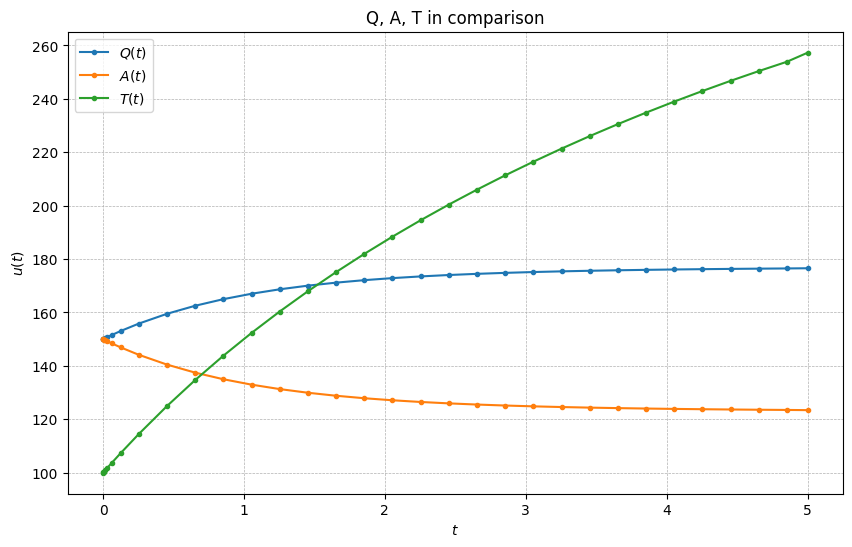

In [670]:
plt.figure(figsize=(10, 6))
plt.plot(t_values, Q_values, marker='.', label='$Q(t)$')
plt.plot(t_values, A_values, marker='.', label='$A(t)$')
plt.plot(t_values, T_values, marker='.', label='$T(t)$')
plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title(f"Q, A, T in comparison")

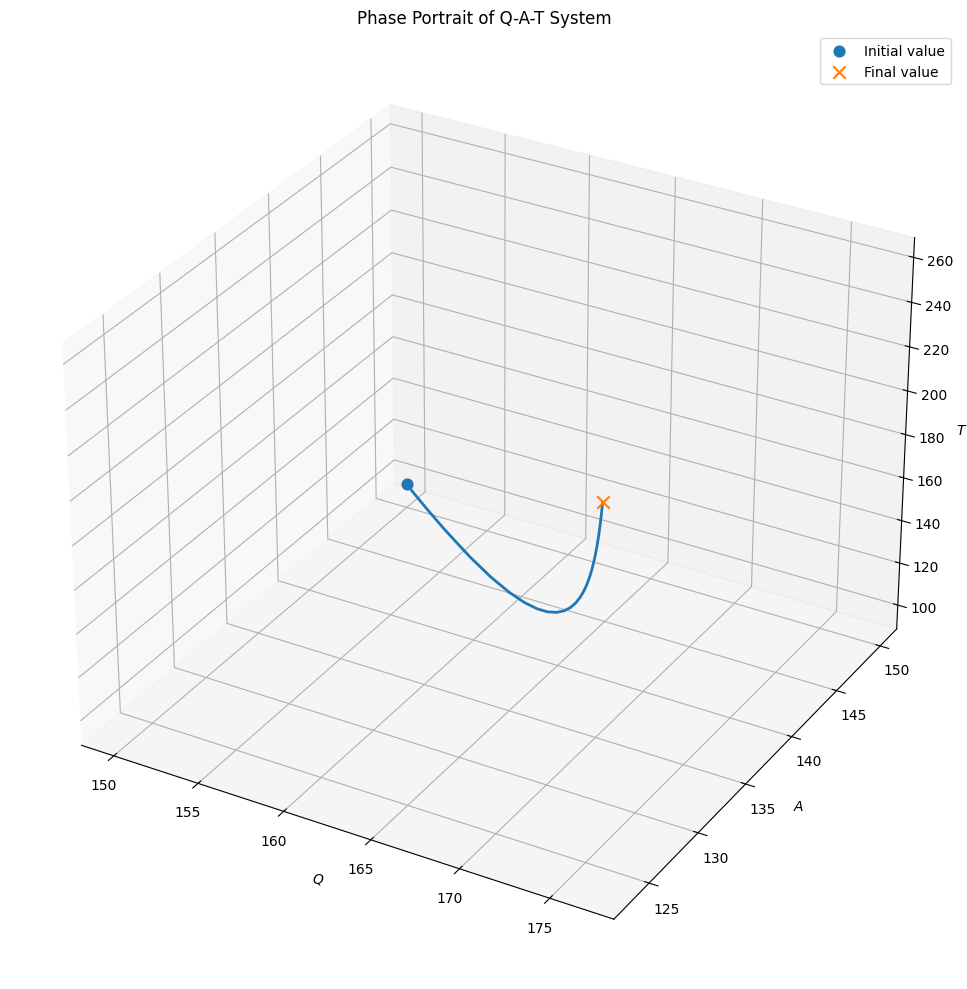

In [671]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")

ax.plot(Q_values, A_values, T_values, linewidth=2)
ax.scatter(Q_values[0], A_values[0], T_values[0],
           s=60, label="Initial value")
ax.scatter(Q_values[-1], A_values[-1], T_values[-1],
           marker="x", s=80, label="Final value")

ax.set_xlabel(r"$Q$")
ax.set_ylabel(r"$A$")
ax.set_zlabel(r"$T$")
ax.set_title("Phase Portrait of Q-A-T System")
ax.legend()

plt.tight_layout()
plt.show()